In [1]:
from bam_utils import *

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import IterableDataset, DataLoader
import itertools

from dataclasses import dataclass
from collections import defaultdict
from typing import Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


### Loading Data

In [2]:
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class LargeIterableDataset(IterableDataset):
    def __init__(self, file_list, max_samples=None, compute_len=False):
        super().__init__()
        self.file_list = list(file_list)
        self.max_samples = max_samples
        self._length = None
        if compute_len:
            self._length = self._count_windows()

    def _count_windows(self):
        count = 0
        for fname in self.file_list:
            data = torch.load(fname, map_location="cpu")
            n = len(data[0]) if hasattr(data[0], "__len__") else data[0].shape[0]
            count += n
            if self.max_samples and count >= self.max_samples:
                return self.max_samples
        return count

    def __iter__(self):
        info = get_worker_info()
        if info is None:
            files = self.file_list
        else:
            # shard files across workers
            files = self.file_list[info.id::info.num_workers]

        emitted = 0
        for fname in files:
            data = torch.load(fname, map_location="cpu")
            x_all, lb_all, pos_all = data[0], data[1], data[2]

            n = len(x_all)
            for i in range(n):
                yield (x_all[i].float(), lb_all[i], pos_all[i])
                emitted += 1
                if self.max_samples and emitted >= self.max_samples:
                    return

    def __len__(self):
        if self._length is None:
            raise TypeError("Length unknown; set compute_len=True to pre-count.")
        return self._length

In [3]:
batch_size=256
nw = 20

test_list = '/home/zouy1/projects/RNAmod/novamod/input/DNA/input_oligos_7mer_new/'+'/test/'
test_list = list(Path(test_list).rglob("*0.pt"))
mod_list ='/home/zouy1/projects/RNAmod/novamod/input/DNA/input_oligos_7mer_new/'+'/mod/'
mod_list =list(Path(mod_list).rglob("*0.pt"))

test_dataset = LargeIterableDataset(test_list, max_samples=200000, compute_len=True)
mod_dataset = LargeIterableDataset(mod_list, max_samples=200000, compute_len=True)

test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)
mod_loader  = DataLoader(mod_dataset,  batch_size=batch_size, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)

### Evaluation

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt

In [5]:
# Import model
import importlib
import models.model_v1_cnn_t as m  # change model here
importlib.reload(m)
model_name = m.META.name

model = m.VAE(
    n_features=11,
    seq_len=7,
    d_model=64,
    cnn_channels=64,
    n_heads=4,
    n_layers=3,
    latent_dim=16,
    dropout=0.1,
    use_cls_token=True,
).to(device)

pt = torch.load("state_dicts/model_v1_cnn_t/model_vae_cnn_be-3_e50.pt", map_location=device)

model.load_state_dict(pt['model_state_dict'])
last_beta = pt['beta']

#check params
num_nonzero = sum((p.abs() > 1e-6).sum().item() for p in model.parameters())
nparam = sum([p.numel() for p in model.parameters()])
print(f"non-zero params: {100*num_nonzero/nparam}%")

/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


non-zero params: 99.99756331041685%


In [6]:
# Anomaly scoring: per-sample reconstruction error
def anomaly_score(model, loader, beta, device):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]
            #kl_score = 0.5 * torch.sum(out["mu"]**2 + out["logvar"].exp() - out["logvar"] - 1, dim=1)
            #elbo_score = recon_score + beta * kl_score
            scores.append(recon_score.detach().cpu())
        print("mu std:", out["mu"].std(dim=0).mean().item())
        print("logvar mean:", out["logvar"].mean().item())
    return torch.cat(scores, dim=0)
scores_test = anomaly_score(model, test_loader, last_beta, device)
scores_mod = anomaly_score(model, mod_loader, last_beta, device)
print(f"unmod score (mean): {scores_test.mean().item()}, mod score (mean): {scores_mod.mean().item()}")

mu std: 0.564115047454834
logvar mean: -2.2628815174102783
mu std: 0.625470757484436
logvar mean: -2.212303638458252
unmod score (mean): 0.010735650546848774, mod score (mean): 0.023264599964022636


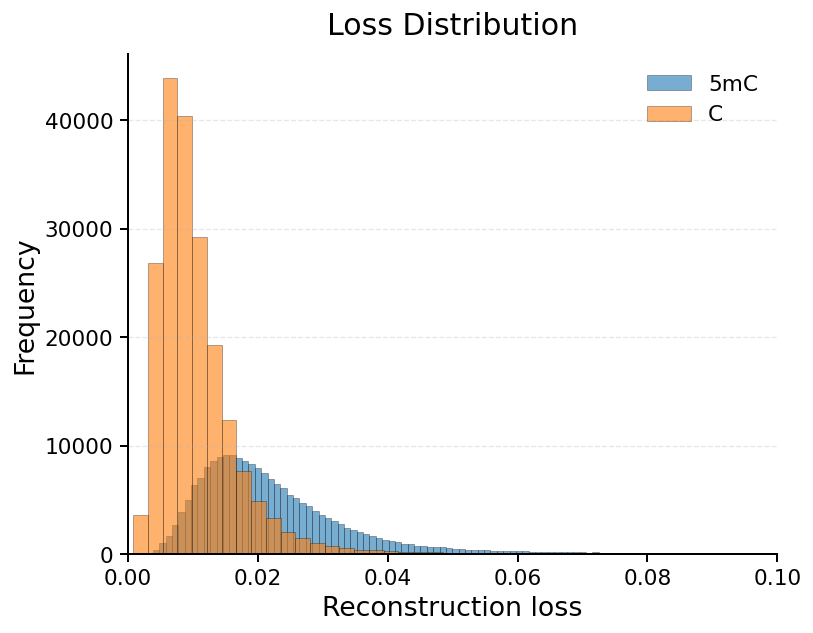

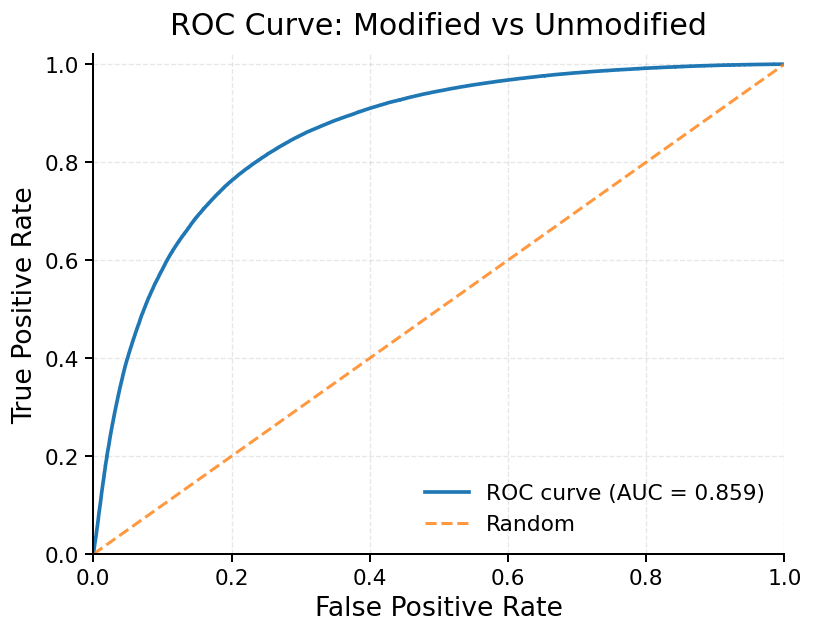

ROC AUC = 0.8588


In [7]:
def labscore(unmod_loss, mod_loss):
    scores = np.concatenate([mod_loss, unmod_loss])
    labels = np.concatenate([np.ones_like(mod_loss), np.zeros_like(unmod_loss)])
    return labels, scores

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (7, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def plotROC(unmod_loss, mod_loss, save_path='figures/ROC_latest.png'):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    all_labels, all_scores = labscore(unmod_loss, mod_loss)
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots()

    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], '--', linewidth=1.8, alpha=0.8, label="Random")
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve: Modified vs Unmodified", pad=12)

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f"ROC AUC = {roc_auc:.4f}")

def plotHist(unmod_loss, mod_loss, save_path='figures/hist_latest.png'):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, ax = plt.subplots()

    ax.hist(mod_loss, bins=200, alpha=0.6, density=False, label='5mC',
            edgecolor='black', linewidth=0.3)
    ax.hist(unmod_loss, bins=200, alpha=0.6, density=False, label='C',
            edgecolor='black', linewidth=0.3)

    ax.set_xlim(0, 0.1)
    ax.set_xlabel("Reconstruction loss")
    ax.set_ylabel("Frequency")
    ax.set_title("Loss Distribution", pad=12)

    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# usage
plotHist(scores_test, scores_mod, save_path="figures/hist_5mC.png")
plotROC(scores_test, scores_mod, save_path="figures/ROC_5mC.png")

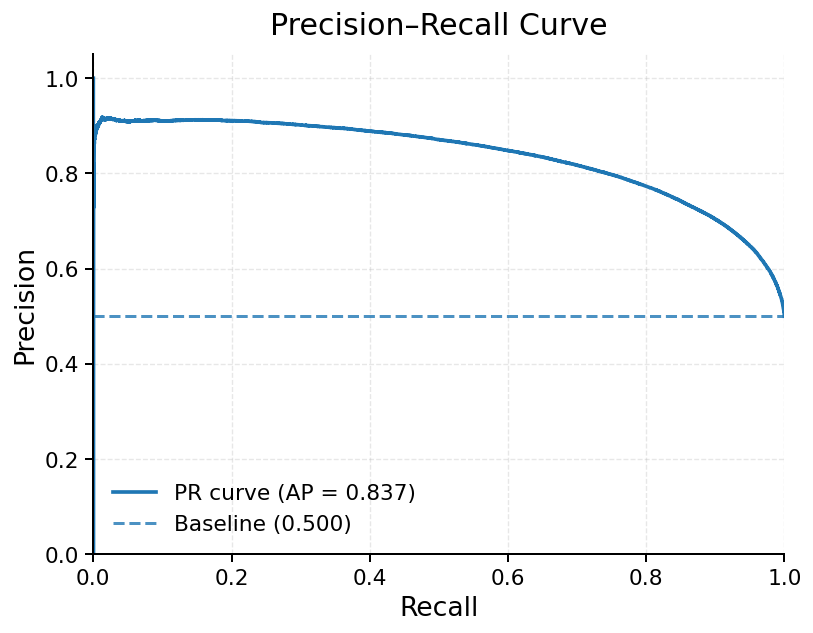

Average Precision = 0.8372
The precision at 0.95 recall is 0.5126


In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import os
import numpy as np
import matplotlib.pyplot as plt

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (7, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def plot_pr_curve(scores, labels, title="Precision–Recall Curve",
                  save_path="./figures/PRC_latest.png"):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    fig, ax = plt.subplots()

    ax.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")

    baseline = labels.mean()
    ax.axhline(baseline, linestyle="--", linewidth=1.8, alpha=0.8,
               label=f"Baseline ({baseline:.3f})")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title, pad=12)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc="lower left")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Average Precision = {ap:.4f}")

labels, scores = labscore(scores_test, scores_mod)
plot_pr_curve(scores, labels, save_path="./figures/PRC_5mC.png")

def precision_at_threshold(scores, labels, recall):
    threshold = torch.quantile(torch.Tensor(scores[labels == 0]), 1.0-recall)
    scores = torch.as_tensor(scores)
    labels = torch.as_tensor(labels)

    preds = (scores >= threshold).long()  # predicted anomalies

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    return precision

target_recall = 0.95
prec = precision_at_threshold(scores, labels, target_recall)
print(f"The precision at {target_recall} recall is {prec:.4f}")

In [70]:
#per k-mer evaluation
base_map = {0: "A", 1: "C", 2: "G", 3: "T"}

def kmer_from_window(x):
    idx = x[:, :4].argmax(dim=1).cpu().numpy()
    return "".join(base_map[int(i)] for i in idx)

def evaluate_per_kmer(model, loader, device="cuda"):
    model.eval()
    loss_dict = defaultdict(list)

    with torch.no_grad():
        for x, lb, pos in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]

            # Decode k-mer for every datum in the batch
            for i in range(x.size(0)):
                kmer = kmer_from_window(x[i])
                loss_dict[kmer].append(float(recon_score[i].detach().cpu()))

    return loss_dict

# {kmer: [loss]}
un_loss = evaluate_per_kmer(model, test_loader)   
mod_loss= evaluate_per_kmer(model, mod_loader)

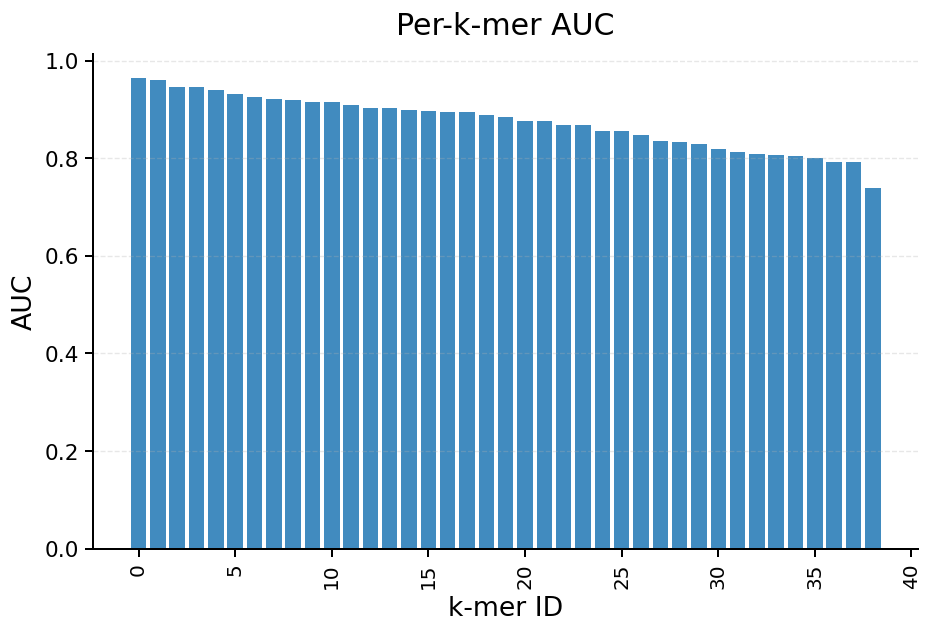

In [71]:
import os
import matplotlib.pyplot as plt

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (8, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def ROCbykmer(un_loss, mod_loss):
    kmer_stats = []
    
    for km in un_loss.keys():
        un_arr = np.array(un_loss[km])
        mod_arr= np.array(mod_loss.get(km, []))
    
        if len(mod_arr) == 0: #skip kmers absent in mod set
            continue
    
        mean_un = un_arr.mean()
        mean_mod= mod_arr.mean()
    
        # ROC for this k-mer
        labels, scores = labscore(un_arr, mod_arr)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        aucs = auc(fpr, tpr)
        kmer_stats.append((km, len(un_arr), len(mod_arr), mean_un, mean_mod, aucs))

    kmer_stats.sort(key=lambda t: t[-1], reverse=True)
    return pd.DataFrame(kmer_stats, columns=['kmer','#un','#mod','mean_un','mean_mod','auc'])
    
aucs = ROCbykmer(un_loss, mod_loss)

def plot_kmer_auc_bar(aucs, save_path="./figures/kmer-bar_latest.png"):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, ax = plt.subplots()

    ax.bar(aucs.index, aucs.auc, alpha=0.85, width=0.8)

    ax.set_xlabel("k-mer ID")
    ax.set_ylabel("AUC")
    ax.set_title("Per-k-mer AUC", pad=12)

    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # useful when there are many kmers
    ax.tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_kmer_auc_bar(aucs, save_path="./figures/kmer_5mC.png")

In [10]:
def evaluate_per_read(model, loader, device="cuda"):
    loss_list, label_list, pos_list = [], [], []
    model.eval()

    with torch.no_grad():
        for x, y, pos in loader:                 # batch
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))

            loss_list.extend(recon_score.detach().cpu().tolist())
            label_list.extend(y.cpu().tolist())
            pos_list.extend(pos.cpu().tolist())

    return loss_list, label_list, pos_list

# aggregate score by position
def aggregate_by_site(losses, labels, positions, agg="mean"):
    score_dict  = defaultdict(list)
    label_dict  = defaultdict(list)

    for s, l, p in zip(losses, labels, positions):
        ps = str(p[2])+'-'+str(p[1])
        score_dict[ps].append(s)
        label_dict[ps].append(l)

    site_score  = []
    site_label  = []

    for p in score_dict:
        vals = np.array(score_dict[p])
        if agg == "median":
            site_score.append(np.median(vals))
        elif agg == "max":
            site_score.append(np.max(vals))
        else:
            site_score.append(np.mean(vals))

        # majority vote for label, or "any-mod" rule
        lab = np.array(label_dict[p])
        site_label.append(int((lab == 1).any()))   # 1 if ≥1 mod read

    return np.array(site_score), np.array(site_label)


loss_r1, lab_r1, pos_r1 = evaluate_per_read(model, test_loader)
loss_r2, lab_r2, pos_r2 = evaluate_per_read(model, mod_loader)
pos_r = [list(t) for t in (set(map(tuple, pos_r1)) & set(map(tuple, pos_r2)))]
score_site1, label_site1 = aggregate_by_site(loss_r1, lab_r1, pos_r, agg="mean")
score_site2, label_site2 = aggregate_by_site(loss_r2, lab_r2, pos_r, agg="mean")
score_site = np.concat([score_site1, score_site2])
label_site = np.concat([label_site1, label_site2])

# ROC at site level
fpr, tpr, thresholds = roc_curve(label_site, score_site)
auc_site = auc(fpr, tpr)

print(f"Site-level ROC-AUC = {auc_site:.3f}  (N_sites = {len(score_site)})")

Site-level ROC-AUC = 1.000  (N_sites = 112)


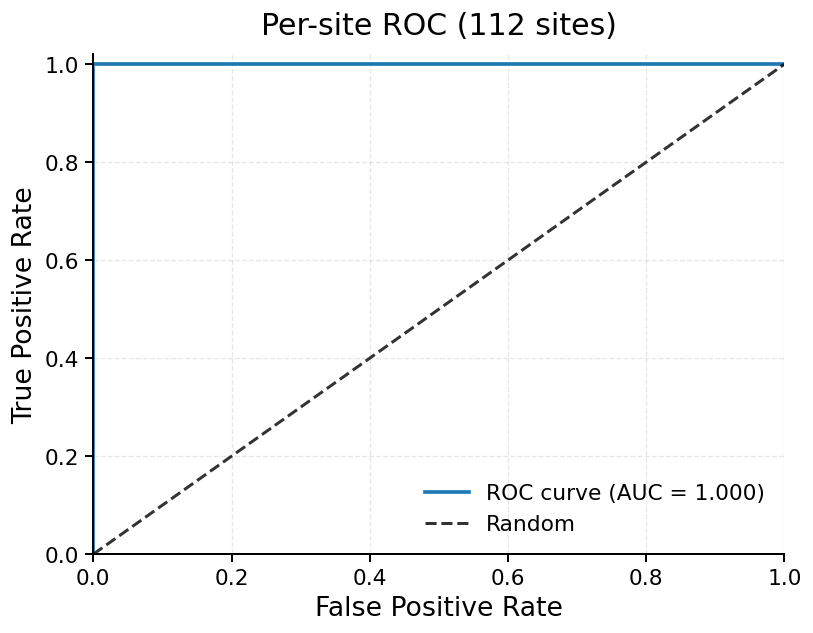

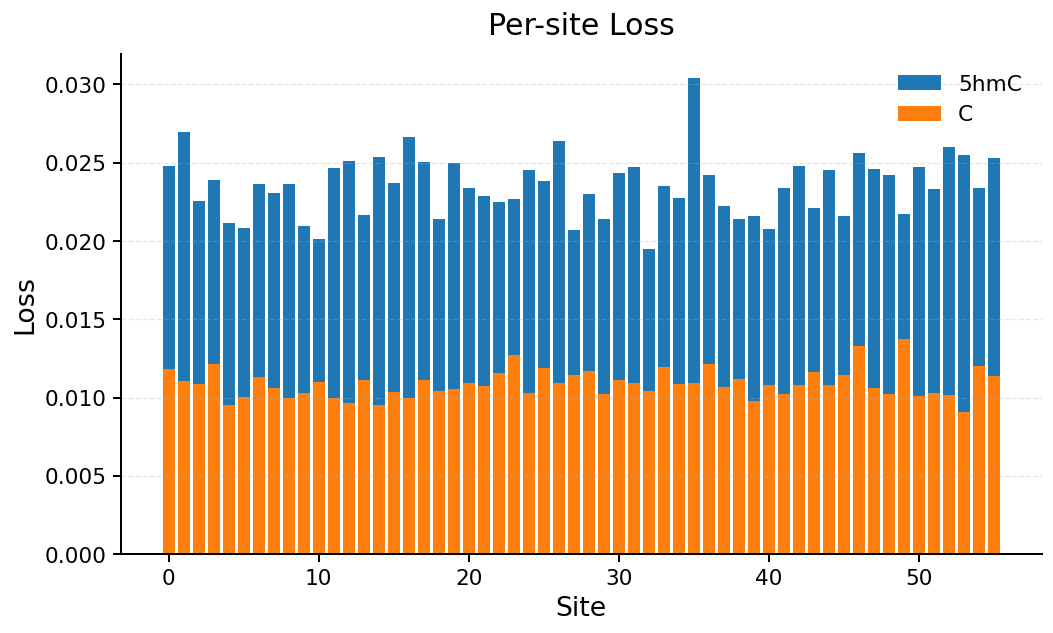

In [11]:
import os
import matplotlib.pyplot as plt

def _set_plot_style():
    plt.rcParams.update({
        "figure.figsize": (7, 5.5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def plotSite(fpr, tpr, auc_site, score_site, save_path="./figures/site-ROC_latest.png"):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, ax = plt.subplots()

    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_site:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.8, alpha=0.8, label="Random")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Per-site ROC ({len(score_site)} sites)", pad=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)

    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc="lower right")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def plotSitebar(score_site1, score_site2, save_path="./figures/site-bar_latest.png"):
    _set_plot_style()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    x1 = list(range(len(score_site1)))
    x2 = list(range(len(score_site2)))

    ax.bar(x2, score_site2, alpha=1, label='5hmC')
    ax.bar(x1, score_site1, alpha=1, label='C')

    ax.set_xlabel("Site")
    ax.set_ylabel("Loss")
    ax.set_title("Per-site Loss", pad=12)

    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plotSite(fpr, tpr, auc_site, score_site, save_path="./figures/site-ROC_5mC.png")
plotSitebar(score_site1, score_site2, save_path="./figures/site-bar-ROC_5mC.png")

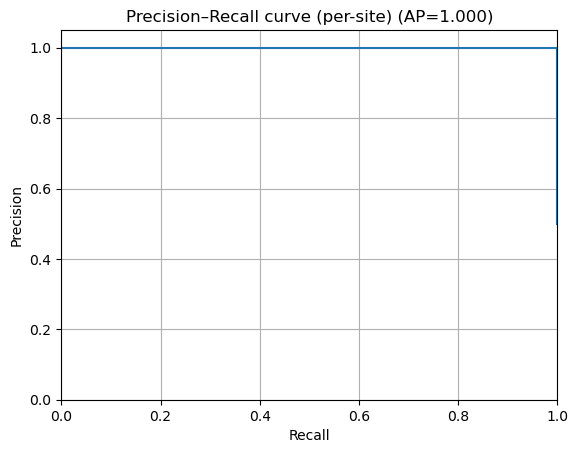

In [75]:
def plot_pr_curve(scores, labels, title="Precision–Recall curve (per-site)"):
    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP={ap:.3f})")
    plt.ylim(0.0, 1.05)
    plt.xlim(0.0, 1.0)
    plt.grid(True)
    plt.savefig("./figures/site-PRC_latest.png", dpi=300)
    plt.show()
    
plot_pr_curve(score_site, label_site)